In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 1. Load dataset with relative path & display first 10 records
df = pd.read_csv('flightdelay.csv')
display(df.head(10))

# 2. Screen features for fraction of unique values > 0.6
print('--- High Cardinality Features (Unique Fraction > 0.6) ---')
high_unique_cols = []
for col in df.columns:
  frac_unique = df[col].nunique() / len(df)
  if frac_unique > 0.6:
    print(f'{col}: {frac_unique:.4f}')
    high_unique_cols.append(col)

# 3. Update dataframe by dropping identified features
df = df.drop(columns=high_unique_cols)
print(f'\nDropped columns: {high_unique_cols}')
print(f'Remaining shape: {df.shape}')

,ID_TAG,DAY_OF_WEEK,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,DEL15
0,1,Saturday,143,Southwest Airlines Co.,13056,107363,1903352,13382999,17,McCarran International,36.08,-115.152,Spokane International,0.0,0.0,0.0,65,2.91,0
1,2,Saturday,175,Southwest Airlines Co.,13056,107363,1903352,13382999,5,McCarran International,36.08,-115.152,Cleveland-Hopkins International,0.0,0.0,0.0,65,2.91,0
2,3,Saturday,175,Southwest Airlines Co.,13056,107363,1903352,13382999,2,McCarran International,36.08,-115.152,Detroit Metro Wayne County,0.0,0.0,0.0,65,2.91,0
3,4,Saturday,143,Southwest Airlines Co.,13056,107363,1903352,13382999,13,McCarran International,36.08,-115.152,San Francisco International,0.0,0.0,0.0,65,2.91,0
4,5,Saturday,175,Southwest Airlines Co.,13056,107363,1903352,13382999,5,McCarran International,36.08,-115.152,Nashville International,0.0,0.0,0.0,65,2.91,1
5,6,Saturday,143,Southwest Airlines Co.,13056,107363,1903352,13382999,19,McCarran International,36.08,-115.152,San Jose International,0.0,0.0,0.0,65,2.91,0
6,7,Saturday,175,Southwest Airlines Co.,13056,107363,1903352,13382999,5,McCarran International,36.08,-115.152,Dallas Love Field,0.0,0.0,0.0,65,2.91,0
7,8,Saturday,143,Southwest Airlines Co.,13056,107363,1903352,13382999,13,McCarran International,36.08,-115.152,Hollywood-Burbank Midpoint,0.0,0.0,0.0,65,2.91,0
8,9,Saturday,234,Delta Air Lines Inc.,13056,73508,1903352,12460183,16,McCarran International,36.08,-115.152,Atlanta Municipal,0.0,0.0,0.0,65,2.91,0
9,10,Saturday,154,United Air Lines Inc.,13056,46218,1903352,8501631,11,McCarran International,36.08,-115.152,San Francisco International,0.0,0.0,0.0,65,2.91,0


--- High Cardinality Features (Unique Fraction > 0.6) ---
ID_TAG: 1.0000

Dropped columns: ['ID_TAG']
Remaining shape: (95159, 18)


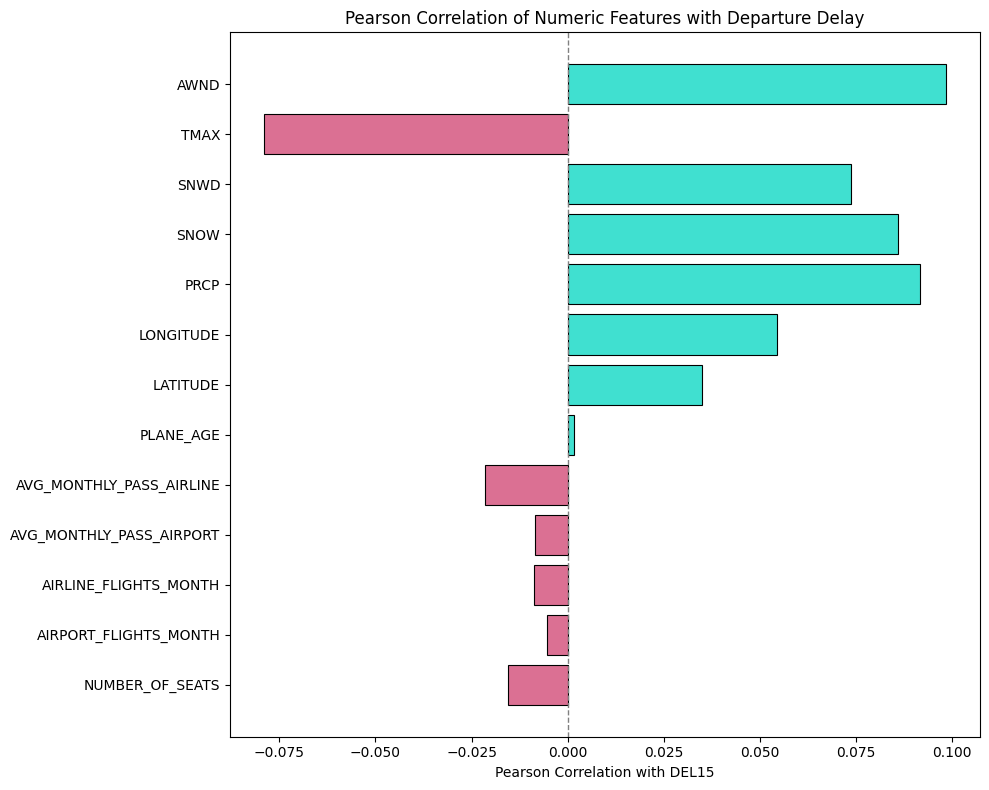

In [2]:
# Separate numeric features and target
target_col = 'DEL15'
numeric_cols = [
    col
    for col in df.select_dtypes(include=[np.number]).columns
    if col != target_col
]

# Calculate Pearson correlations
pearson_corr = df[numeric_cols].apply(lambda x: x.corr(df[target_col]))

# Set custom bar colors: palevioletred for negative, turquoise for positive
bar_colors = [
    'palevioletred' if val < 0 else 'turquoise' for val in pearson_corr.values
]

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
y_positions = np.arange(len(numeric_cols))

ax.barh(
    y_positions,
    pearson_corr.values,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8,
)
ax.set_yticks(y_positions)
ax.set_yticklabels(numeric_cols)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Pearson Correlation with DEL15')
ax.set_title('Pearson Correlation of Numeric Features with Departure Delay')
plt.tight_layout()
plt.show()

In [3]:
# Statistical significance testing (alpha = 0.05)
print(
    f"{'Feature Name':<30} | {'Pearson r':<10} | {'p-value':<12} | {'Significant (p <= 0.05)'}"
)
print('-' * 70)

cols_to_drop = []
for col in numeric_cols:
  # Drop NaNs pairwise if present for Pearson test
  clean_pair = df[[col, target_col]].dropna()
  r_val, p_val = stats.pearsonr(clean_pair[col], clean_pair[target_col])

  is_sig = p_val <= 0.05
  print(f'{col:<30} | {r_val:10.5f} | {p_val:<12.4e} | {is_sig}')

  if not is_sig:
    cols_to_drop.append(col)

# Drop features with p-value > 0.05
df = df.drop(columns=cols_to_drop)
print(f'\nDropped insignificant features (p > 0.05): {cols_to_drop}')
print(f'Remaining shape: {df.shape}')

Feature Name                   | Pearson r  | p-value      | Significant (p <= 0.05)
----------------------------------------------------------------------
NUMBER_OF_SEATS                |   -0.01558 | 1.5349e-06   | True
AIRPORT_FLIGHTS_MONTH          |   -0.00545 | 9.2707e-02   | False
AIRLINE_FLIGHTS_MONTH          |   -0.00865 | 7.5880e-03   | True
AVG_MONTHLY_PASS_AIRPORT       |   -0.00843 | 9.3322e-03   | True
AVG_MONTHLY_PASS_AIRLINE       |   -0.02162 | 2.5543e-11   | True
PLANE_AGE                      |    0.00177 | 5.8413e-01   | False
LATITUDE                       |    0.03497 | 3.7996e-27   | True
LONGITUDE                      |    0.05434 | 3.7898e-63   | True
PRCP                           |    0.09158 | 2.6192e-176  | True
SNOW                           |    0.08583 | 4.8212e-155  | True
SNWD                           |    0.07376 | 6.4519e-115  | True
TMAX                           |   -0.07896 | 1.8849e-131  | True
AWND                           |    0.09838 | 2.94

/usr/local/lib/python3.13/dist-packages/phik/significance.py:339: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_binned.groupby([c0, c1])[c0].count().to_frame().unstack().fillna(0)
/usr/local/lib/python3.13/dist-packages/phik/significance.py:339: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_binned.groupby([c0, c1])[c0].count().to_frame().unstack().fillna(0)
/usr/local/lib/python3.13/dist-packages/phik/significance.py:339: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

,phik_corr,p_value
DEPARTING_AIRPORT,0.167366,37.445838
PREVIOUS_AIRPORT,0.137812,25.565854
AWND,0.135020,29.958723
TMAX,0.133223,29.057844
PRCP,0.124093,26.228653
LATITUDE,0.121585,27.948876
SNWD,0.117381,24.672649
CARRIER_NAME,0.101474,27.155541
AVG_MONTHLY_PASS_AIRPORT,0.096911,21.383081
LONGITUDE,0.080122,24.259211


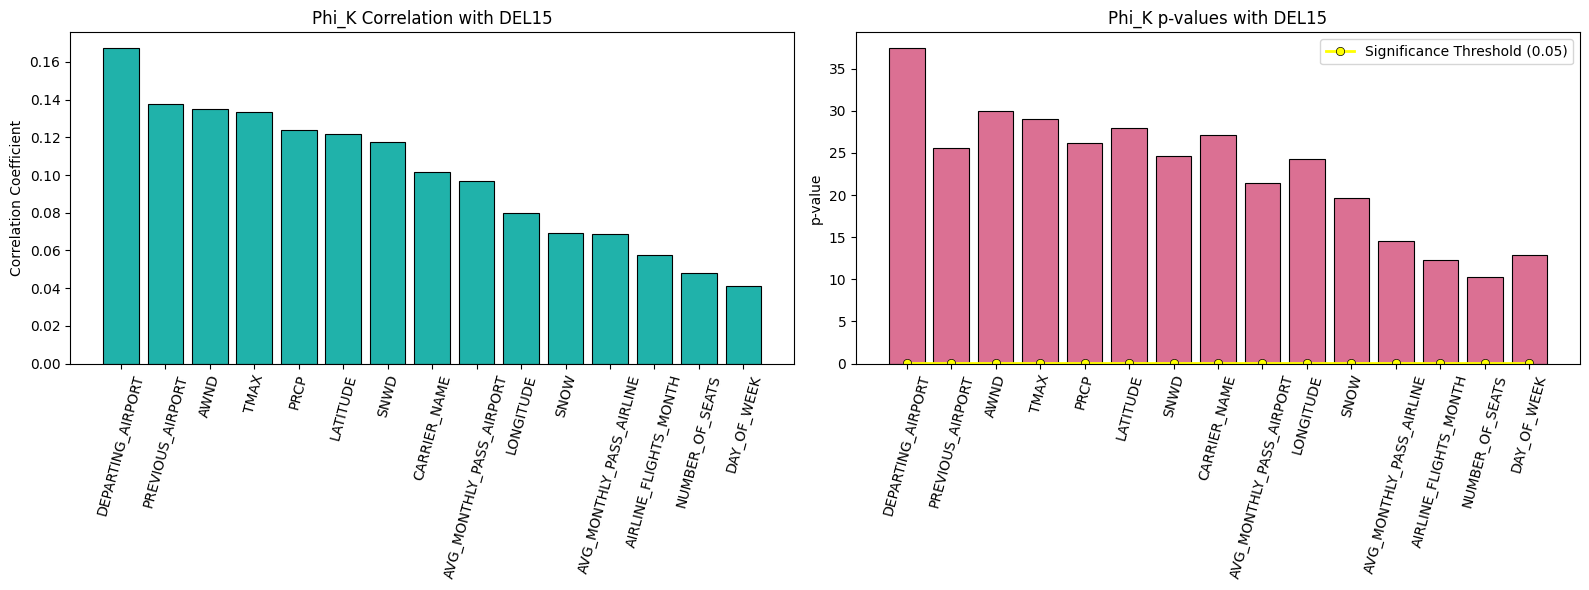

In [11]:
import phik
from phik.report import correlation_report, plot_correlation_matrix

# Define interval (continuous) columns minus target and categorical columns
categorical_cols = [
    'CARRIER_NAME',
    'DEPARTING_AIRPORT',
    'PREVIOUS_AIRPORT',
    'DAY_OF_WEEK',
]
interval_cols = [
    col
    for col in df.select_dtypes(include=[np.number]).columns
    if col != target_col and col not in categorical_cols
]

# Convert non-interval columns to category datatype
for col in df.columns:
  if col not in interval_cols:
    df[col] = df[col].astype('category')

# Compute Phi_K correlation and significance against DEL15
phik_vals = []
phik_pvals = []
features_tested = [col for col in df.columns if col != target_col]

for col in features_tested:
  sub_df = df[[col, target_col]].dropna()
  # Determine phik correlation
  val = sub_df.phik_matrix(interval_cols=interval_cols).loc[col, target_col]
  # Determine significance / p-value
  sig_matrix = sub_df.significance_matrix(interval_cols=interval_cols)
  pval = sig_matrix.loc[col, target_col] if sig_matrix is not None else 0.0

  phik_vals.append(val)
  phik_pvals.append(pval)

# Create summary DataFrame sorted by Phi_K descending
phik_df = pd.DataFrame(
    {'phik_corr': phik_vals, 'p_value': phik_pvals}, index=features_tested
).sort_values(by='phik_corr', ascending=False)

display(phik_df)

# Dual bar plot: Phi_K correlations and p-values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Phi_K Correlations
axes[0].bar(
    phik_df.index,
    phik_df['phik_corr'],
    color='lightseagreen',
    edgecolor='black',
    linewidth=0.8,
)
axes[0].set_title('Phi_K Correlation with DEL15')
axes[0].set_ylabel('Correlation Coefficient')
axes[0].tick_params(axis='x', rotation=75)

# Plot p-values
axes[1].bar(
    phik_df.index,
    phik_df['p_value'],
    color='palevioletred',
    edgecolor='black',
    linewidth=0.8,
)
axes[1].plot(
    phik_df.index,
    [0.05] * len(phik_df.index),
    color='yellow',
    markeredgecolor='black',  # Subtle border for visibility
    markeredgewidth=0.5,
    linestyle='-',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Significance Threshold (0.05)',
)
axes[1].set_title('Phi_K p-values with DEL15')
axes[1].set_ylabel('p-value')
axes[1].tick_params(axis='x', rotation=75)
axes[1].legend()

plt.tight_layout()
plt.show()

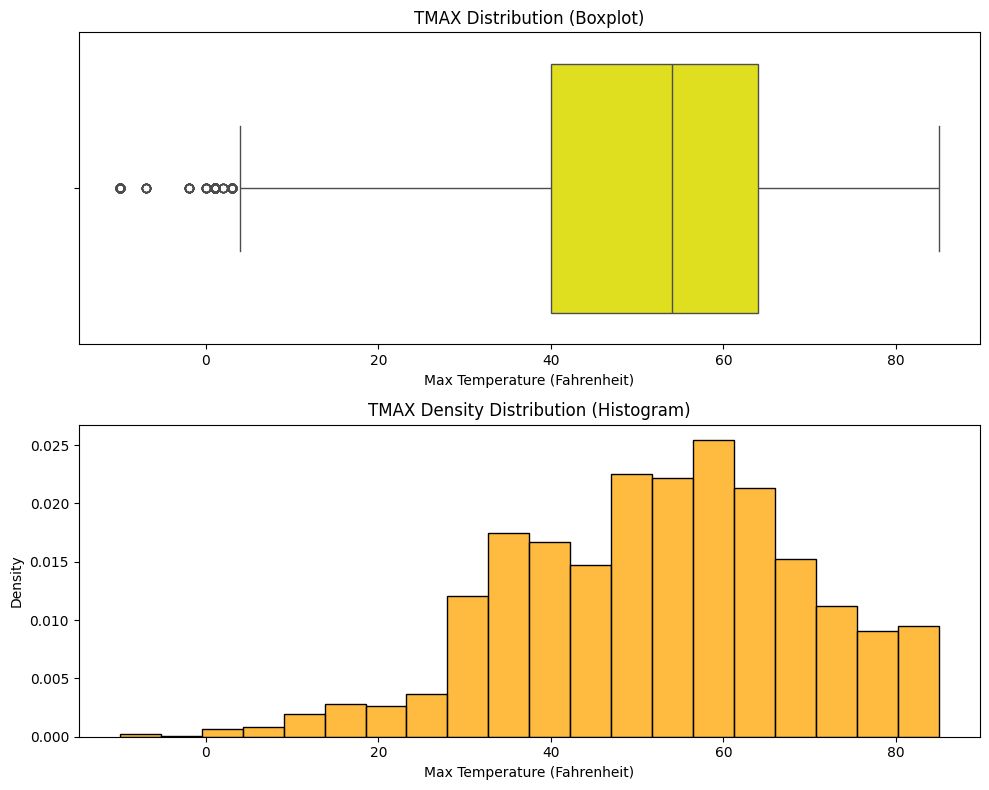

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# 1. Horizontal Boxplot
sns.boxplot(x=df['TMAX'], color='yellow', ax=axes[0])
axes[0].set_title('TMAX Distribution (Boxplot)')
axes[0].set_xlabel('Max Temperature (Fahrenheit)')

# 2. Histogram with Density (20 Bins, Non-Blue Color)
sns.histplot(df['TMAX'], bins=20, color='orange', stat='density', ax=axes[1])
axes[1].set_title('TMAX Density Distribution (Histogram)')
axes[1].set_xlabel('Max Temperature (Fahrenheit)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [19]:
# Calculate Q1, Q3, and IQR
Q1 = df['TMAX'].quantile(0.25)
Q3 = df['TMAX'].quantile(0.75)
IQR = Q3 - Q1

# Define lower bound and clip
lower_bound = Q1 - 1.5 * IQR
df['TMAX'] = df['TMAX'].clip(lower=lower_bound)

print(f"Lower Bound Fence: {lower_bound}")
print("Lower outliers successfully clipped.")

Lower Bound Fence: 4.0
Lower outliers successfully clipped.


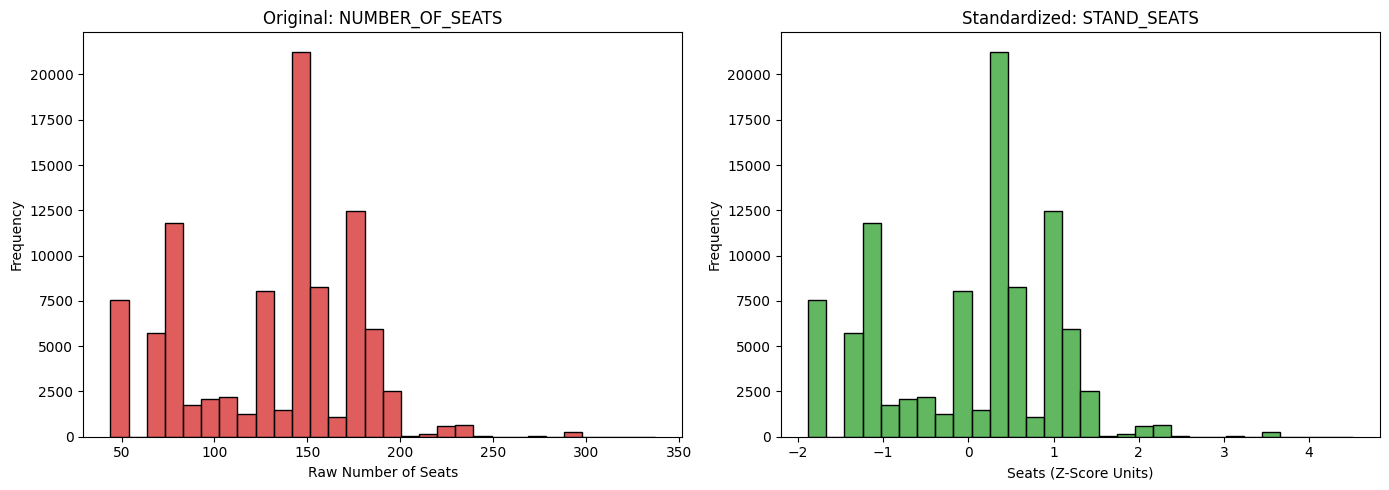

Standardized Mean: 0.0000
Standardized Std Dev: 1.0000


In [21]:
from sklearn.preprocessing import StandardScaler

# Standardize NUMBER_OF_SEATS
scaler = StandardScaler()
df['STAND_SEATS'] = scaler.fit_transform(df[['NUMBER_OF_SEATS']])

# Plotting distributions Before and After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Plot
sns.histplot(df['NUMBER_OF_SEATS'], bins=30, color='tab:red', ax=axes[0])
axes[0].set_title('Original: NUMBER_OF_SEATS')
axes[0].set_xlabel('Raw Number of Seats')
axes[0].set_ylabel('Frequency')

# Standardized Plot
sns.histplot(df['STAND_SEATS'], bins=30, color='tab:green', ax=axes[1])
axes[1].set_title('Standardized: STAND_SEATS')
axes[1].set_xlabel('Seats (Z-Score Units)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Quick verification print
print(f"Standardized Mean: {df['STAND_SEATS'].mean():.4f}")
print(f"Standardized Std Dev: {df['STAND_SEATS'].std():.4f}")

In [22]:
from sklearn.preprocessing import LabelEncoder

# Perform Label Encoding
le = LabelEncoder()
df['LE_CARRIER_NAME'] = le.fit_transform(df['CARRIER_NAME'])

# Verify unique categories using the shape parameter
unique_original = df['CARRIER_NAME'].unique().shape[0]
unique_encoded = df['LE_CARRIER_NAME'].unique().shape[0]

print(f"Unique categories in CARRIER_NAME: {unique_original}")
print(f"Unique categories in LE_CARRIER_NAME: {unique_encoded}")

Unique categories in CARRIER_NAME: 17
Unique categories in LE_CARRIER_NAME: 17
